In [97]:
import random as random
import numpy as np

# Tinh so pi
# Tinh tich phan bang Monte Carlo

### Monte Carlo Integration

Giả sử chúng ta có một khu đất hình chữ nhật, và ở giữa có một cái hồ với hình dạng bất kỳ.

Ta muốn tính diện tích của cái hồ này.

Ý tưởng của phương pháp Monte Carlo là:

- Tưởng tượng ta ném thật nhiều viên sỏi một cách ngẫu nhiên lên toàn bộ khu đất.
- Sau đó, đếm xem có bao nhiêu viên rơi **vào trong hồ** và bao nhiêu viên rơi **trong toàn bộ khu đất**.
- Khi số lượng điểm ném đủ lớn, tỉ lệ

  \[
  \frac{N_{\text{hồ}}}{N_{\text{khu đất}}}
  \]

  sẽ xấp xỉ bằng

  \[
  \frac{A_{\text{hồ}}}{A_{\text{khu đất}}}.
  \]

Từ đó, ta suy ra diện tích của hồ:

\[
A_{\text{hồ}} \approx A_{\text{khu đất}} \times \frac{N_{\text{hồ}}}{N_{\text{khu đất}}}.
\]

Đây chính là ý tưởng của **Monte Carlo integration**: dùng các điểm ngẫu nhiên để ước lượng tích phân xác định, hay trực quan hơn là để tính diện tích.

### Ví dụ

Một ví dụ rất nổi tiếng là dùng Monte Carlo để xấp xỉ số \(\pi\):

- Xét một hình vuông cạnh \(2\) và một hình tròn nội tiếp.
- Ném ngẫu nhiên các điểm vào trong hình vuông.
- Đếm số điểm rơi vào bên trong hình tròn.
- Từ tỉ lệ số điểm nằm trong hình tròn so với tổng số điểm, ta có thể suy ra giá trị gần đúng của \(\pi\).

In [93]:
import random

def luu_file_chuadiem(x_list, y_list, filename):
    with open(filename, "w", encoding="utf-8") as file:
        file.write(f"# File chua thong tin toa do cua cac diem {filename}\n")
        file.write("#" * 50 + "\n")
        file.write(f"#{'i':>6s}  {'x':>12s}  {'y':>12s}\n")

        for i in range(len(x_list)):
            file.write(f"{i+1:6d}  {x_list[i]:12.9f}  {y_list[i]:12.9f}\n")


def uoctinh_pi_montecarlo(N):
    dem_trong_vong_tron = 0
    x_trong = []
    y_trong = []
    x_ngoai = []
    y_ngoai = []

    for i in range(N):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)

        if x**2 + y**2 <= 1:
            x_trong.append(x)
            y_trong.append(y)
            dem_trong_vong_tron += 1
        else:
            x_ngoai.append(x)
            y_ngoai.append(y)

    pi_xapsi = 4 * dem_trong_vong_tron / N

    return pi_xapsi, dem_trong_vong_tron, x_trong, y_trong, x_ngoai, y_ngoai


N = 10000

pi_xapsi, dem_trong_vong_tron, x_trong, y_trong, x_ngoai, y_ngoai = uoctinh_pi_montecarlo(N)

luu_file_chuadiem(x_trong, y_trong, "bentrong.txt")
luu_file_chuadiem(x_ngoai, y_ngoai, "benngoai.txt")

print("So diem trong duong tron:", dem_trong_vong_tron)
print("Tong so diem:", N)
print(f"Gia tri xap xi cua pi: {pi_xapsi:.9f}")

So diem trong duong tron: 7930
Tong so diem: 10000
Gia tri xap xi cua pi: 3.172000000


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


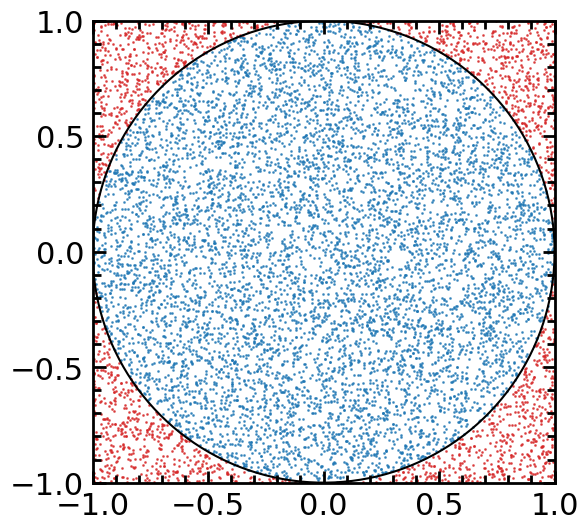

In [99]:
import matplotlib.pyplot as plt
plt.style.use('sci.mplstyle')

i_trong, x_trong, y_trong = np.loadtxt('bentrong.txt', unpack=True, comments="#")
i_ngoai, x_ngoai, y_ngoai = np.loadtxt('benngoai.txt', unpack=True, comments="#")

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(x_trong, y_trong, s=1, color= 'C0', alpha= 0.7)
ax.scatter(x_ngoai, y_ngoai, s=1, color= 'C1', alpha =0.7)

#x_square = [-1,  1,  1, -1, -1]
#y_square = [-1, -1,  1,  1, -1]
#ax.plot(x_square, y_square, linewidth=1.5,color= 'black')


# Ve duong tron tam (0,0), ban kinh 1
theta = np.linspace(0, 2*np.pi, 500)
x_circle = np.cos(theta)
y_circle = np.sin(theta)
ax.plot(x_circle, y_circle, linewidth=1.5,color = 'black')

# Chinh hinh
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.legend()

plt.savefig("monte_carlo_python.pdf")
plt.show()


In [127]:
def luu_file_hoitu(n_tinh_pi,pi_uoctinh_N):
    with open("Ketquahoitu.txt", "w", encoding="utf-8") as file:
        file.write(f"# File chua thong tin hoi tu cua pi theo N\n")
        file.write("#" * 50 + "\n")
        file.write(f"#{'N':>20s}  {'pi':>20s}\n")

        for i in range(len(n_tinh_pi)):
            file.write(f"{n_tinh_pi[i]:20d}  {pi_uoctinh_N[i]:20.9f}\n")

N_max  = 100000

def tinhhoitu(N_max):
    pi_uoctinh_N = []
    n_tinh_pi = []

    for n in range(N_max):
        if n > 2 and np.mod(n,50) == 0:
            pi_xapsi, dem_trong_vong_tron, x_trong, y_trong, x_ngoai, y_ngoai = uoctinh_pi_montecarlo(n)
            n_tinh_pi.append(n) 
            pi_uoctinh_N.append(pi_xapsi)

    luu_file_hoitu(n_tinh_pi,pi_uoctinh_N)

tinhhoitu(N_max)


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_21345/3375077178.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Gia tri uoc tinh $\pi$')


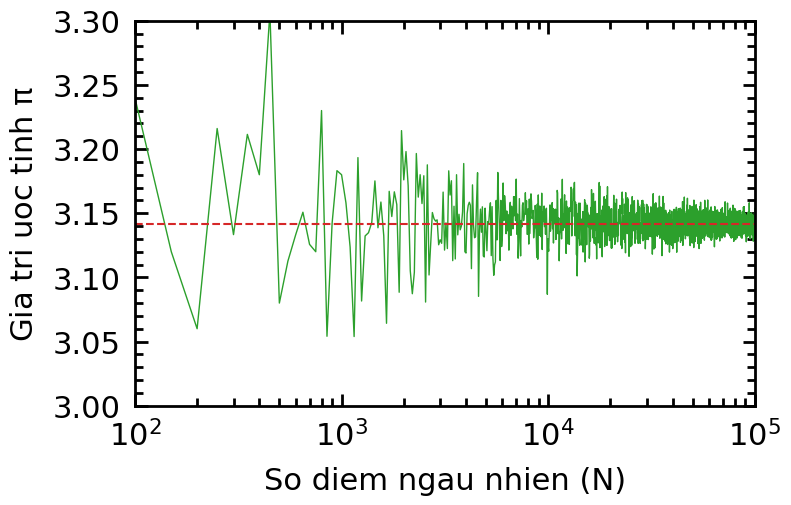

In [132]:
plt.figure(figsize=(8,5))

N, pi = np.loadtxt("Ketquahoitu.txt",unpack=True, comments="#")

plt.semilogx(N,pi, color='C2', lw = 1)
plt.axhline(np.pi, color='C1', linestyle = '--', lw = 1.5)
plt.ylim(3.0,3.3)
plt.xlim(1e2,1e5)
plt.xlabel('So diem ngau nhien (N)')
plt.ylabel('Gia tri uoc tinh $\pi$')
plt.tick_params(axis='both', pad=10)

plt.savefig("Ket_qua_hoi_tu_theo_N.pdf")
plt.show()

## Tính tích phân

Xét tích phân:

\[
S=\int_a^b f(x)\,dx
\]

### 1. Phương pháp tổng Riemann

Chia đoạn \([a,b]\) thành \(N\) đoạn nhỏ, mỗi đoạn có độ dài:

\[
h=\frac{b-a}{N}
\]

Khi đó, tích phân được xấp xỉ bởi tổng Riemann:

\[
S \approx h\sum_{n=1}^{N} f(x_n)
\]

trong đó \(x_n\) là các điểm được chọn trong từng đoạn con.

- Khi \(N\) càng lớn thì \(h\) càng nhỏ.
- Khi đó giá trị xấp xỉ càng chính xác.
- Sai số được xem là giảm theo bậc \(O(h^2)\).

Phương pháp này tương đương với việc chia miền tích phân một cách có chủ đích và lấy mẫu có hệ thống.

---

### 2. Phương pháp Monte Carlo

Thay vì chia đều đoạn \([a,b]\), ta chọn ngẫu nhiên các điểm:

\[
x_1, x_2, \dots, x_N \in [a,b]
\]

Nếu \(N\) đủ lớn, các điểm này sẽ phân bố đều trên miền \([a,b]\).

Giá trị trung bình của hàm được ước lượng bởi:

\[
\langle f \rangle = \frac{1}{N}\sum_{n=1}^{N} f(x_n)
\]

Suy ra tích phân được xấp xỉ bởi:

\[
S \approx (b-a)\langle f \rangle
\]

hay:

\[
S \approx (b-a)\frac{1}{N}\sum_{n=1}^{N} f(x_n)
\]

---

### 3. Sai số của phương pháp Monte Carlo

Độ lệch chuẩn của phép tính Monte Carlo được cho bởi:

\[
(\delta_S)^2=\frac{1}{N}\left(\langle f^2\rangle-\langle f\rangle^2\right)
\]

trong đó:

\[
\langle f^2\rangle=\frac{1}{N}\sum_{n=1}^{N} f(x_n)^2
\]

Sai số của Monte Carlo giảm theo:

\[
\delta_S \sim \frac{1}{\sqrt{N}}
\]

Điều này có nghĩa là muốn tăng độ chính xác thì phải tăng số lượng mẫu ngẫu nhiên.

---

## Thuật toán Monte Carlo

```text
S = 0
for i = 1 -> N
    Chọn ngẫu nhiên x trong [a, b]
    S = S + f(x)

S = (b - a) * S / N

In [149]:
def tich_phan_monte_carlo(a,b,N,hamso):
    S = 0
    x_plot = []
    y_plot = []
    for i in range(N):
        x  = np.random.uniform(a,b)
        x_plot.append(x)
        y_plot.append(hamso(x))
        S = S + hamso(x)
    ketqua =  (b-a) * S/N
    return ketqua

N = 10000
a = 0
b = 5

def hamso_1(x):
    y = x**2
    return y

S_giai_tich = 41.6667

err_conv = 1e-3

print(f"{tich_phan_monte_carlo(a, b, N, hamso_1):.6f}")

41.593660


In [150]:
N_max  = 100000
for i in range(N_max):
    if i > 5 and np.mod(i,100) == 0:
        ketqua = tich_phan_monte_carlo(a,b,i,hamso_1)
        err = np.abs(ketqua-S_giai_tich)
        if err < err_conv:
            q = i

print(f"So luong x ngau nhien can dung de dat do sai so mong muon la: {q}")

So luong x ngau nhien can dung de dat do sai so mong muon la: 76600


### Tính tích phân hai lớp bằng phương pháp Monte Carlo

Xét tích phân hai lớp:

\[
S = \int_a^b \int_c^d f(x,y)\,dx\,dy
\]

Ý tưởng của phương pháp Monte Carlo là lấy ngẫu nhiên nhiều điểm \((x_i, y_i)\) phân bố đều trong miền hình chữ nhật \([a,b]\times[c,d]\), rồi dùng giá trị trung bình của hàm số trên các điểm đó để xấp xỉ tích phân.

Ta có:

\[
\langle f \rangle = \frac{1}{N}\sum_{i=1}^{N} f(x_i,y_i)
\]

Do đó:

\[
S \approx (b-a)(d-c)\,\langle f \rangle
\]

hay:

\[
S \approx (b-a)(d-c)\,\frac{1}{N}\sum_{i=1}^{N} f(x_i,y_i)
\]

### Thuật toán

```text
S = 0

for i = 1, 2, ..., N
    Chọn ngẫu nhiên x trong [a,b]
    Chọn ngẫu nhiên y trong [c,d]
    S = S + f(x,y)

ANS = (b-a)(d-c) * S / N

In [155]:
def tich_phan_monte_carlo_2D(a,b,c,d,N,hamso):
    S = 0
    for i in range(N):
        x  = np.random.uniform(a,b)
        y  = np.random.uniform(c,d)
        S = S + hamso(x,y)
    ketqua =  (b-a) * (d-c) * S/N
    return ketqua

def hamso_2D(x,y):
    s = x*y
    return s

a = 3
b = 6
c = 2
d = 8
N = 1000000

tich_phan_monte_carlo_2D(a,b,c,d,N,hamso_2D)

404.88786194805476

In [ ]:
N = 1000000

def hamso_2D_1(x,y):
    s = np.cos(x**4)+3*y**2
    return s
def hamso_2D_2(x,y):
    s = x*np.sin(x+y)
    return s

a1 = 4
b1 = 6
c1 = 0
d1 = 1

a2 = 0
b2 = np.pi/2
c2 = 0
d2 = np.pi/2

ketqua1 = tich_phan_monte_carlo_2D(a1,b1,c1,d1,N,hamso_2D_1)
ketqua2 = tich_phan_monte_carlo_2D(a2,b2,c2,d2,N,hamso_2D_2)

print(f"Ket qua ham so 1 la: {ketqua1:.7f}")
print(f"Ket qua ham so 2 la: {ketqua2:.7f}")

Ket qua ham so 1 la: 2.0026638
Ket qua ham so 2 la: 1.5688181
